# Visualización del dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/iquitos_indice_calor.csv", parse_dates=["fecha_hora"])
df.head()

,fecha_hora,temperatura,punto_rocio,anio,mes,hora,humedad_relativa,indice_calor
0,2000-01-01 00:00:00-05:00,25.0,24.0,2000,1,0,94.191012,26.014988
1,2000-01-01 01:00:00-05:00,25.0,23.6,2000,1,1,91.951467,25.956511
2,2000-01-01 02:00:00-05:00,25.0,24.0,2000,1,2,94.191012,26.014988
3,2000-01-01 03:00:00-05:00,24.0,23.0,2000,1,3,94.148645,24.913881
4,2000-01-01 04:00:00-05:00,23.0,23.0,2000,1,4,100.000000,23.966667


## El dia tipico de Iquitos

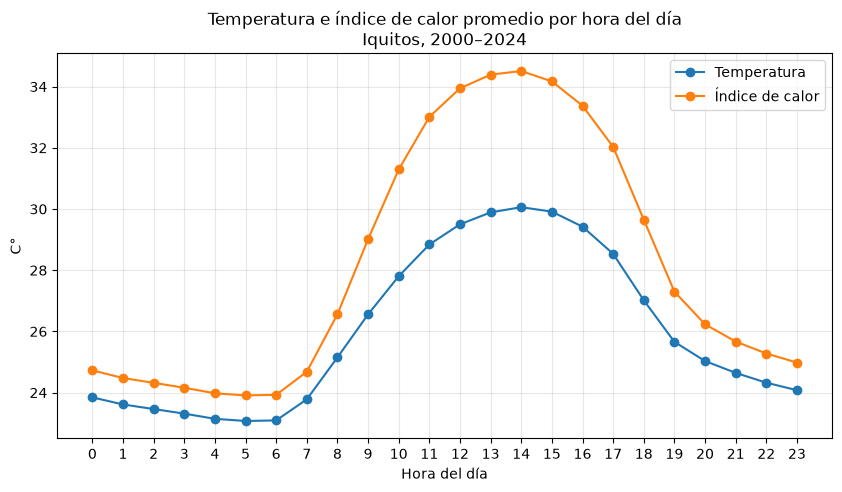

In [3]:
import matplotlib.pyplot as plt

# Promedio de cada variable para cada hora del día
perfil = df.groupby("hora")[["temperatura", "indice_calor"]].mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(perfil.index, perfil["temperatura"], marker="o", label="Temperatura")
ax.plot(perfil.index, perfil["indice_calor"], marker="o", label="Índice de calor")

ax.set_title("Temperatura e índice de calor promedio por hora del día\nIquitos, 2000–2024")
ax.set_xlabel("Hora del día")
ax.set_ylabel("C°")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(alpha=0.3)

plt.savefig("../images/perfil_horario.png", dpi=150, bbox_inches="tight")
plt.show()

- El calor es mas intenso a las 14:00 horas del dia
- La mayor diferencia entre la Temperatura y el Índice de calor es a las 14:00, con una diferencia de 4 C°
- No hay una hora donde las dos linea se toquen, cuando es muy seco deberia estar juntas

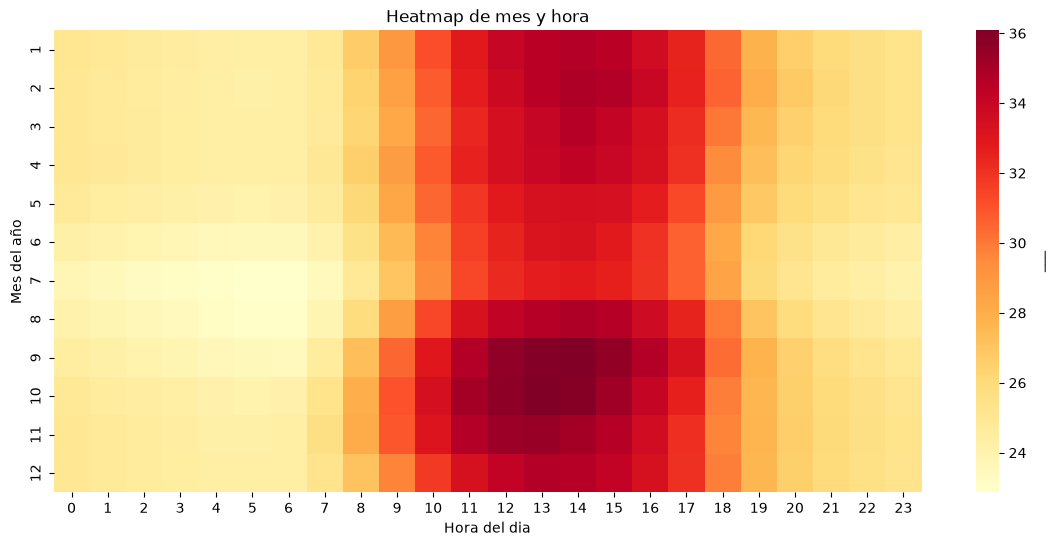

In [5]:
import seaborn as sns

tabla = df.pivot_table(index="mes", columns="hora", values="indice_calor", aggfunc="mean")
tabla

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(tabla, cmap="YlOrRd", ax=ax, cbar_kws={"label": "___"})

ax.set_title("Heatmap de mes y hora")
ax.set_xlabel("Hora del dia")
ax.set_ylabel("Mes del año")

plt.savefig("../images/heatmap_indice_calor.png", dpi=150, bbox_inches="tight")
plt.show()

Gracias al gráfico podemos notar que en las horas de 12:00 a 15:00 de setiembre a octubre presenta mayor temperatura.